In [1]:
import numpy as np
import matplotlib.pyplot as plt
import MyBasics as tools
import random as rd
import os
from scipy.stats import ttest_ind,mannwhitneyu

In [3]:
def plot_significance(list_1,list_2,x1,x2,y1,y2,y_offset,fontsize,linewidth):
    t,p = mannwhitneyu(list_1,list_2)
    print(p)
    if p <= 0.05:
        plt.plot([x1,x1,x2,x2], [y1,max(y1+y_offset, y2+y_offset),max(y1+y_offset, y2+y_offset),y2], linewidth=linewidth, color='k')
    if p <= 0.05 and p > 0.01:
        plt.text((x1+x2)/2,max(y1+y_offset, y2+y_offset)+y_offset,'*',fontsize=fontsize,horizontalalignment='center',va='top')
    elif p <= 0.01 and p > 0.001:
        plt.text((x1+x2)/2,max(y1+y_offset, y2+y_offset)+y_offset,'**',fontsize=fontsize,horizontalalignment='center',va='top')
    elif p <= 0.001 and p > 0.0001:
        plt.text((x1+x2)/2,max(y1+y_offset, y2+y_offset)+y_offset,'***',fontsize=fontsize,horizontalalignment='center',va='top')
    elif p <= 0.0001:
        plt.text((x1+x2)/2,max(y1+y_offset, y2+y_offset)+y_offset,'****',fontsize=fontsize,horizontalalignment='center',va='top')
    return p

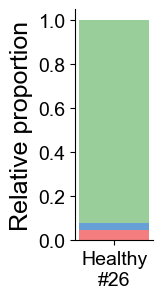

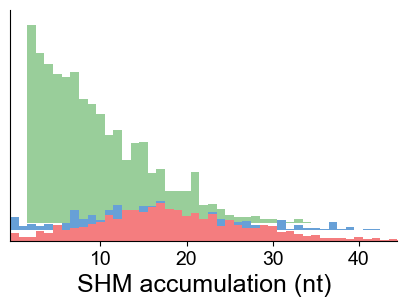

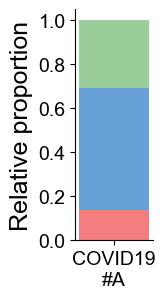

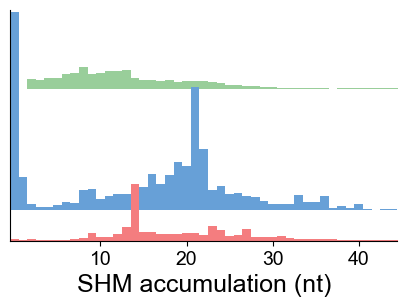

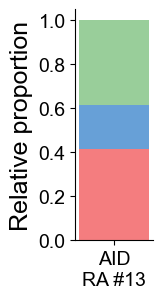

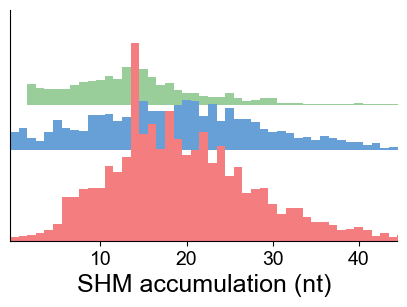

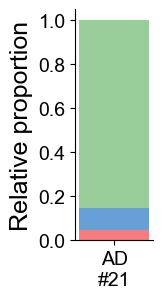

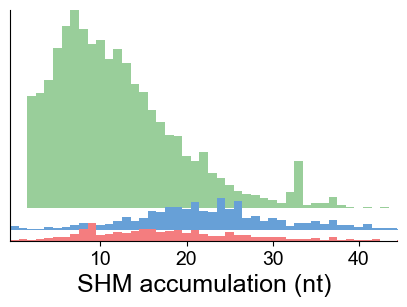

In [11]:
repertoire_file_list = [
    'BCR-map_intermediate_files/pre-26.tsv',
    'BCR-map_intermediate_files/A_d11_e1_a1_f1_c1.tsv',
    'BCR-map_intermediate_files/RA13_RF+.tsv',
    'BCR-map_intermediate_files/SNUBH-21-1_e1_a1_f1_c1.tsv'
]
label_list = [
    'Healthy\n#26','COVID19\n#A','AID\nRA #13','AD\n#21'
]
for r,repertoire_file in enumerate(repertoire_file_list):
    new_list = tools.read_tsv(repertoire_file)
    header = new_list[0]
    c_index = header.index('c_call')
    shm_index = header.index('v_alignment_mutation')
    freq_index = header.index('frequency')
    isotype_val = np.zeros(3)
    shm_val = np.zeros((3,100))
    c_dict = {'IGHM':0,'IGHD':0,'IGHG3':1,'IGHG1':1,'IGHA1':2,'IGHG2':1,'IGHG4':1,'IGHGP':1,'IGHE':2,'IGHA2':2}
    for line in new_list[1:]:
        c = line[c_index].split('*')[0]
        freq = float(line[freq_index])
        shm = int(line[shm_index])
        isotype_val[c_dict[c]] += freq
        if c not in ['IGHM','IGHD'] or shm > 1:
            shm_val[c_dict[c],shm] += freq

    color_list = ['#99CE9A', '#67A0D7', '#F47D7F']
    plt.rcParams["figure.figsize"] = (1,3) 
    fig,ax = plt.subplots(1,1)
    bottom = 0
    fontsize = 20
    bottom_list = []
    for i in range(3):
        bottom_list.append(bottom)
        plt.bar(0,isotype_val[2-i],bottom=bottom,color=color_list[2-i],width=1)
        bottom += isotype_val[2-i]

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.ylim(0,1.05)
    plt.yticks(font='arial',fontsize=fontsize-6)
    #plt.xticks([0],['COVID19\n#A'],font='arial',fontsize=fontsize-6)
    #plt.xticks([0],['AID\nRA #13'],font='arial',fontsize=fontsize-6)
    #plt.xticks([0],['AD\n#21'],font='arial',fontsize=fontsize-6)
    plt.xticks([0],[label_list[r]],font='arial',fontsize=fontsize-6)
    plt.ylabel('Relative proportion',font='arial',fontsize=fontsize-2)
    plt.show()


    plt.rcParams["figure.figsize"] = (5,3) 
    fig,ax = plt.subplots(1,1)
    max_val = max(max(shm_val[0,:]),max(shm_val[1,:]),max(shm_val[2,:]))
    for i in range(3):
        plt.bar(range(100),0.9*shm_val[i,:]/max_val,bottom=bottom_list[2-i]*np.ones(100),color=color_list[i],width=1)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.yticks([])
    plt.xticks([10,20,30,40],['10','20','30','40'],font='arial',fontsize=fontsize-6)
    plt.xlabel('SHM accumulation (nt)',font='arial',fontsize=fontsize-2)
    plt.xlim(-0.5,44.5)
    plt.ylim(0,1.05)
    plt.show()

6.055829657896832e-10


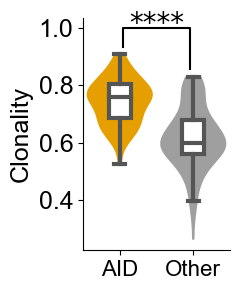

In [4]:
case_dict = {
    'Covid_vaccination_pre_throughput':0,'Covid':1,'Sjogren':2,'RA':2,'NMO':2,'MOG':2,'AD':3
}
temp_list = tools.read_csv('BCR-map_intermediate_files/M_shm_1mid10_10high_clonality.csv')
condition1_list = [[],[],[],[]]
condition2_list = [[],[],[],[]]
for line in temp_list[1:]:
    condition1_list[case_dict[line[0]]].append(float(line[2]))
    condition2_list[case_dict[line[0]]].append(float(line[3]))
color_list = ['#E69F00','#9F9F9F']

max_val = 0
min_val = 100
max_list = [[]]
width=0.8
spacer=0.4
linewidth=3
scatter_size=50

plt.rcParams["figure.figsize"] = (2.5, 3)
fig,ax = plt.subplots(1,1)

box = [[condition2_list[0]],[condition2_list[1]+condition2_list[2]+condition2_list[3]]]
for b,val_list in enumerate(box):
    parts = plt.violinplot(val_list,positions = [b],showmeans=False, showmedians=False,
    showextrema=False, widths=0.9)
    plt.boxplot(val_list, positions=[b], widths=[0.3], patch_artist=True, showfliers=False,
                boxprops={'facecolor': 'w', 'edgecolor': '#555555', 'linewidth': linewidth},
                whiskerprops={'color': '#555555', 'linewidth': linewidth},
                capprops={'color': '#555555', 'linewidth': linewidth},
                medianprops={'color': '#555555', 'linewidth': linewidth})

    for pc in parts['bodies']:
        pc.set_facecolor(color_list[b])
        pc.set_edgecolor('none')
        #pc.set_linewidth(linewdith)
        pc.set_alpha(1)
    max_val = max(max_val, max(val_list[0]))
    min_val = min(min_val, min(val_list[0]))
    max_list[0].append([max(val_list[0]),max(val_list[0])])

y_bias = 0.02 * (max_val - min_val)
x_bias = 0.05
for i in range(len(box)):
    for j in range(2):
        max_list[0][i][j] += 2*y_bias
 
for i in range(1,2):
    for j in range(2-i):
        if 0 in [j,j+i]:
           
            p = plot_significance(box[j][0], box[j+i][0], j+x_bias, j+i-x_bias,
                                  max_list[0][j][1], max_list[0][j+i][0], 5*y_bias, 20, 1.5)

            if p <= 0.05:
                top = max(max_list[0][j][1],max_list[0][j+i][0]) + 3.5*y_bias
                for k in range(j,j+i+1):
                    if k == j:
                        max_list[0][k][1] = top
                    elif k == j+i:
                        max_list[0][k][0] = top
                    else:
                        max_list[0][k][0] = top
                        max_list[0][k][1] = top
                    

                    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Clonality',font='arial',fontsize=18)
plt.xticks(range(2),['HC','Other'],font='arial',fontsize = 16)
plt.yticks(font='arial',fontsize = 18)
plt.tight_layout()
plt.show()

4.728264276460775e-10


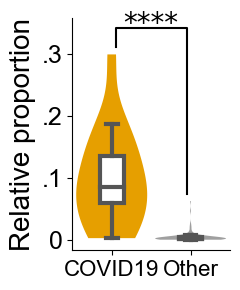

In [5]:
case_dict = {
    'Covid_vaccination_pre_throughput':0,'Covid':1,'Sjogren':2,'RA':2,'NMO':2,'MOG':2,'AD':3
}
temp_list = tools.read_csv('BCR-map_intermediate_files/G1_SHM_total.csv')
condition1_list = [[],[],[],[]]
condition2_list = [[],[],[],[]]
for line in temp_list[1:]:
    condition1_list[case_dict[line[0]]].append(float(line[2])/100)
    condition2_list[case_dict[line[0]]].append(float(line[3])/100)

color_list = ['#E69F00','#9F9F9F']

max_val = 0
min_val = 100
max_list = [[]]
width=0.8
spacer=0.4
linewidth=3
scatter_size=50

plt.rcParams["figure.figsize"] = (2.5, 3)
fig,ax = plt.subplots(1,1)

box = [[condition1_list[1]],[condition1_list[0]+condition1_list[2]+condition1_list[3]]]
for b,val_list in enumerate(box):
    parts = plt.violinplot(val_list,positions = [b],showmeans=False, showmedians=False,
    showextrema=False, widths=0.9)
    plt.boxplot(val_list, positions=[b], widths=[0.3], patch_artist=True, showfliers=False,
                boxprops={'facecolor': 'w', 'edgecolor': '#555555', 'linewidth': linewidth},
                whiskerprops={'color': '#555555', 'linewidth': linewidth},
                capprops={'color': '#555555', 'linewidth': linewidth},
                medianprops={'color': '#555555', 'linewidth': linewidth})

    for pc in parts['bodies']:
        pc.set_facecolor(color_list[b])
        pc.set_edgecolor('none')
        pc.set_alpha(1)
    max_val = max(max_val, max(val_list[0]))
    min_val = min(min_val, min(val_list[0]))
    max_list[0].append([max(val_list[0]),max(val_list[0])])

y_bias = 0.02 * (max_val - min_val)
x_bias = 0.05
for i in range(len(box)):
    for j in range(2):
        max_list[0][i][j] += 2*y_bias
 
for i in range(1,2):
    for j in range(2-i):
        if 0 in [j,j+i]:
           
            p = plot_significance(box[j][0], box[j+i][0], j+x_bias, j+i-x_bias,
                                  max_list[0][j][1], max_list[0][j+i][0], 5*y_bias, 20, 1.5)

            if p <= 0.05:
                top = max(max_list[0][j][1],max_list[0][j+i][0]) + 3.5*y_bias
                #top = max(max_list[0][j][1],max_list[0][j+i][0])*3
                for k in range(j,j+i+1):
                    if k == j:
                        max_list[0][k][1] = top
                    elif k == j+i:
                        max_list[0][k][0] = top
                    else:
                        max_list[0][k][0] = top
                        max_list[0][k][1] = top
                    

                    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Relative proportion',font='arial',fontsize=20)
plt.xticks(range(2),['COVID19','Other'],font='arial',fontsize = 16)
plt.yticks([0,0.1,0.2,0.3],['0','.1','.2','.3'],font='arial',fontsize = 18)
plt.tight_layout()
plt.show()

6.055829657896832e-10


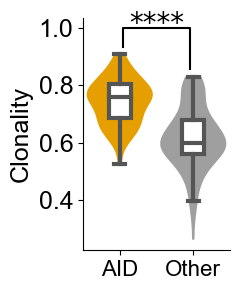

In [6]:
case_dict = {
    'Covid_vaccination_pre_throughput':0,'Covid':1,'Sjogren':2,'RA':2,'NMO':2,'MOG':2,'AD':3
}

temp_list = tools.read_csv('BCRmap/A2_clonality.csv')

condition1_list = [[],[],[],[]]
condition2_list = [[],[],[],[]]
for line in temp_list[1:]:
    condition1_list[case_dict[line[0]]].append(float(line[2]))
    condition2_list[case_dict[line[0]]].append(float(line[3]))

color_list = ['#E69F00','#9F9F9F']

max_val = 0
min_val = 100
max_list = [[]]
width=0.8
spacer=0.4
linewidth=3
scatter_size=50

plt.rcParams["figure.figsize"] = (2.5, 3)
fig,ax = plt.subplots(1,1)

box = [[condition1_list[2]],[condition1_list[0]+condition1_list[1]+condition1_list[3]]]    
for b,val_list in enumerate(box):
    parts = plt.violinplot(val_list,positions = [b],showmeans=False, showmedians=False,
    showextrema=False, widths=0.9)
    plt.boxplot(val_list, positions=[b], widths=[0.3], patch_artist=True, showfliers=False,
                boxprops={'facecolor': 'w', 'edgecolor': '#555555', 'linewidth': linewidth},
                whiskerprops={'color': '#555555', 'linewidth': linewidth},
                capprops={'color': '#555555', 'linewidth': linewidth},
                medianprops={'color': '#555555', 'linewidth': linewidth})

    for pc in parts['bodies']:
        pc.set_facecolor(color_list[b])
        pc.set_edgecolor('none')
        pc.set_alpha(1)
    max_val = max(max_val, max(val_list[0]))
    min_val = min(min_val, min(val_list[0]))
    max_list[0].append([max(val_list[0]),max(val_list[0])])

y_bias = 0.02 * (max_val - min_val)
x_bias = 0.05
for i in range(len(box)):
    for j in range(2):
        max_list[0][i][j] += 2*y_bias
 
for i in range(1,2):
    for j in range(2-i):
        if 0 in [j,j+i]:
           
            p = plot_significance(box[j][0], box[j+i][0], j+x_bias, j+i-x_bias,
                                  max_list[0][j][1], max_list[0][j+i][0], 5*y_bias, 20, 1.5)

            if p <= 0.05:
                top = max(max_list[0][j][1],max_list[0][j+i][0]) + 3.5*y_bias
                for k in range(j,j+i+1):
                    if k == j:
                        max_list[0][k][1] = top
                    elif k == j+i:
                        max_list[0][k][0] = top
                    else:
                        max_list[0][k][0] = top
                        max_list[0][k][1] = top
                    

                    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Clonality',font='arial',fontsize=18)
plt.xticks(range(2),['AID','Other'],font='arial',fontsize = 16)
plt.yticks(font='arial',fontsize = 18)
plt.tight_layout()
plt.show()

1.39680603580108e-06


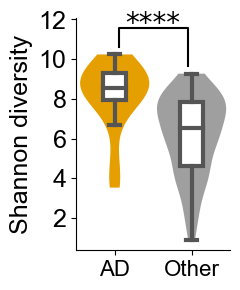

In [8]:
case_dict = {
    'Covid_vaccination_pre_throughput':0,'Covid':1,'Sjogren':2,'RA':2,'NMO':2,'MOG':2,'AD':3
}
temp_list = tools.read_csv('BCRmap/M_shannon_total.csv')
condition1_list = [[],[],[],[]]
condition2_list = [[],[],[],[]]
for line in temp_list[1:]:
    condition1_list[case_dict[line[0]]].append(float(line[2]))
    condition2_list[case_dict[line[0]]].append(float(line[3]))
color_list = ['#E69F00','#9F9F9F']

max_val = 0
min_val = 100
max_list = [[]]
width=0.8
spacer=0.4
linewidth=3
scatter_size=50

plt.rcParams["figure.figsize"] = (2.5, 3)
fig,ax = plt.subplots(1,1)

box = [[condition1_list[3]],[condition1_list[0]+condition1_list[1]+condition1_list[2]]]
    
for b,val_list in enumerate(box):
    parts = plt.violinplot(val_list,positions = [b],showmeans=False, showmedians=False,
    showextrema=False, widths=0.9)
    plt.boxplot(val_list, positions=[b], widths=[0.3], patch_artist=True, showfliers=False,
                boxprops={'facecolor': 'w', 'edgecolor': '#555555', 'linewidth': linewidth},
                whiskerprops={'color': '#555555', 'linewidth': linewidth},
                capprops={'color': '#555555', 'linewidth': linewidth},
                medianprops={'color': '#555555', 'linewidth': linewidth})

    for pc in parts['bodies']:
        pc.set_facecolor(color_list[b])
        pc.set_edgecolor('none')
        pc.set_alpha(1)
    max_val = max(max_val, max(val_list[0]))
    min_val = min(min_val, min(val_list[0]))
    max_list[0].append([max(val_list[0]),max(val_list[0])])

y_bias = 0.02 * (max_val - min_val)
x_bias = 0.05
for i in range(len(box)):
    for j in range(2):
        max_list[0][i][j] += 2*y_bias
 
for i in range(1,2):
    for j in range(2-i):
        if 0 in [j,j+i]:
           
            p = plot_significance(box[j][0], box[j+i][0], j+x_bias, j+i-x_bias,
                                  max_list[0][j][1], max_list[0][j+i][0], 5*y_bias, 20, 1.5)

            if p <= 0.05:
                top = max(max_list[0][j][1],max_list[0][j+i][0]) + 3.5*y_bias
                for k in range(j,j+i+1):
                    if k == j:
                        max_list[0][k][1] = top
                    elif k == j+i:
                        max_list[0][k][0] = top
                    else:
                        max_list[0][k][0] = top
                        max_list[0][k][1] = top
                    

                    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Shannon diversity',font='arial',fontsize=18)
plt.xticks(range(2),['AD','Other'],font='arial',fontsize = 16)
plt.yticks(font='arial',fontsize = 18)
plt.tight_layout()
plt.show()